In [6]:
# Library & Dataset

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Create dataset
X = np.random.randn(100, 2)

# Decision boundary: x1 + x2 > 0 → class 1
y = (X[:, 0] + X[:, 1] > 0).astype(int).reshape(-1, 1)

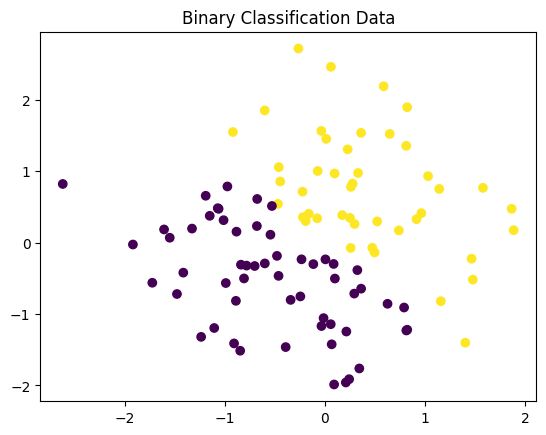

In [7]:
# Visualize

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Binary Classification Data")
plt.show()

In [9]:
# Initialize Parameters

W = np.random.randn(2, 1)
b = np.random.randn(1)

In [10]:
# Sigmoid Function

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [11]:
# Forward Pass

def predict_proba(X, W, b):
    return sigmoid(X @ W + b)

In [12]:
# Loss Function (Binary Cross Entropy)

def compute_loss(y, y_pred):
    m = len(y)
    return -np.mean(
        y * np.log(y_pred + 1e-8) + 
        (1 - y) * np.log(1 - y_pred + 1e-8)
    )

In [13]:
# Gradients

def compute_gradients(X, y, y_pred):
    m = len(X)
    
    dW = (1/m) * X.T @ (y_pred - y)
    db = (1/m) * np.sum(y_pred - y)
    
    return dW, db

In [14]:
# Training Loop

learning_rate = 0.1
epochs = 500

losses = []

for epoch in range(epochs):
    y_pred = predict_proba(X, W, b)
    
    loss = compute_loss(y, y_pred)
    losses.append(loss)
    
    dW, db = compute_gradients(X, y, y_pred)
    
    W -= learning_rate * dW
    b -= learning_rate * db
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 0.670697757250502
Epoch 50, Loss: 0.32319898349415505
Epoch 100, Loss: 0.2513025809011436
Epoch 150, Loss: 0.21868520687424373
Epoch 200, Loss: 0.1983998311254874
Epoch 250, Loss: 0.18392453566417782
Epoch 300, Loss: 0.17281490900007238
Epoch 350, Loss: 0.16389387857974583
Epoch 400, Loss: 0.15650267366923512
Epoch 450, Loss: 0.15023529688637627


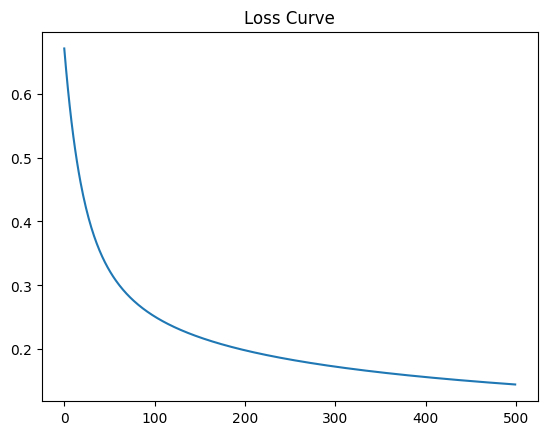

In [15]:
# Plot Loss

plt.plot(losses)
plt.title("Loss Curve")
plt.show()

In [17]:
# Prediction

def predict(X, W, b):
    probs = predict_proba(X, W, b)
    return (probs >= 0.5).astype(int)

# Accuracy

y_pred_labels = predict(X, W, b)

accuracy = np.mean(y_pred_labels == y)
print("Accuracy:", accuracy)

Accuracy: 0.99
